# Intermolecular interactions, van der Waals gases, and condensation

Numerical exercises to go with the reading material on molecular interactions (kjm1130).

This notebook has three parts:

1. The Lennard-Jones potential - plotting the pair potential for real molecules
2. The van der Waals equation of state - why real gases deviate from the ideal gas law
3. A small 2D molecular simulation - watching a Lennard-Jones gas condense, and computing the pair correlation function g(r)

Run each cell in order (Shift+Enter). You don't need to understand every line of code on first read - focus on changing the numbers marked `# <- try changing this` and seeing what happens to the plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["font.size"] = 11

## Part 1 - The Lennard-Jones potential

$$u_{LJ}(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right]$$

Two parameters describe the whole curve:

- $\varepsilon$ (epsilon) - the well depth, i.e. how strongly the molecules attract each other at the optimal distance
- $\sigma$ (sigma) - roughly the molecular diameter; the potential crosses zero at $r = \sigma$

The table below has real Lennard-Jones parameters for a few gases (from standard reference tables), given as $\varepsilon/k_B$ in kelvin, so you can directly compare the well depth to a temperature.

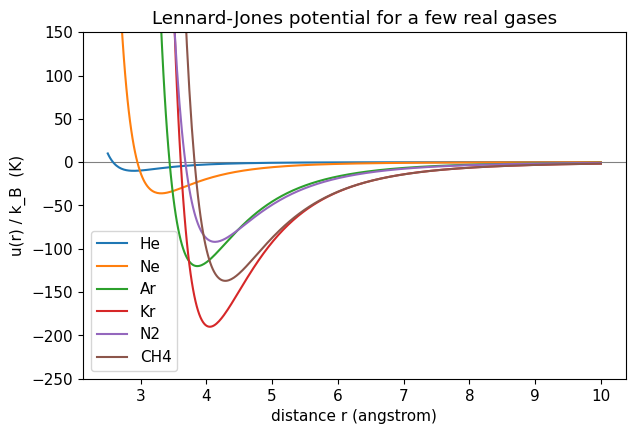

In [2]:
# Lennard-Jones parameters for a few real gases
# eps_over_k is epsilon/k_B in kelvin, sigma is in angstrom
lj_params = {
    "He":  {"eps_over_k": 10,  "sigma": 2.58},
    "Ne":  {"eps_over_k": 36,  "sigma": 2.95},
    "Ar":  {"eps_over_k": 120, "sigma": 3.44},
    "Kr":  {"eps_over_k": 190, "sigma": 3.61},
    "N2":  {"eps_over_k": 92,  "sigma": 3.68},
    "CH4": {"eps_over_k": 137, "sigma": 3.82},
}

def lj_potential(r, eps_over_k, sigma):
    """Lennard-Jones potential energy, in units of kelvin (i.e. u/k_B), for separation r in angstrom."""
    sr6 = (sigma / r) ** 6
    return 4 * eps_over_k * (sr6**2 - sr6)

r = np.linspace(2.5, 10, 400)

plt.axhline(0, color="gray", linewidth=0.8)
for name, p in lj_params.items():
    plt.plot(r, lj_potential(r, p["eps_over_k"], p["sigma"]), label=name)

plt.xlabel("distance r (angstrom)")
plt.ylabel("u(r) / k_B  (K)")
plt.ylim(-250, 150)
plt.legend()
plt.title("Lennard-Jones potential for a few real gases")
plt.show()

**Questions to think about:**

- Which molecule has the deepest potential well? Which has the shallowest?
- Argon's well depth is $\varepsilon/k_B \approx 120$ K. Room temperature is about 298 K - is $k_BT$ bigger or smaller than the well depth? What does that tell you about whether argon is a gas or a liquid at room temperature?
- Try adding your own gas to the `lj_params` dictionary (look up its Lennard-Jones parameters) and see where it falls on the plot.

## Part 2 - The van der Waals equation and the compressibility factor

The ideal gas law $pV = nRT$ assumes molecules don't interact and take up no space. Real gases deviate from this. The **compressibility factor**

$$Z = \frac{pV_m}{RT}$$

is exactly 1 for an ideal gas. Anything else tells you molecules are interacting.

The van der Waals equation patches the ideal gas law with two corrections:

$$\left(p + \frac{a}{V_m^2}\right)(V_m - b) = RT$$

- $b$ accounts for the volume molecules themselves take up (excluded volume) - this pushes $Z$ *above* 1 at high pressure
- $a$ accounts for the attraction between molecules - this pulls $Z$ *below* 1 at moderate pressure

We'll compute $Z$ as a function of pressure directly from this equation, using real $a$ and $b$ values for a few gases.

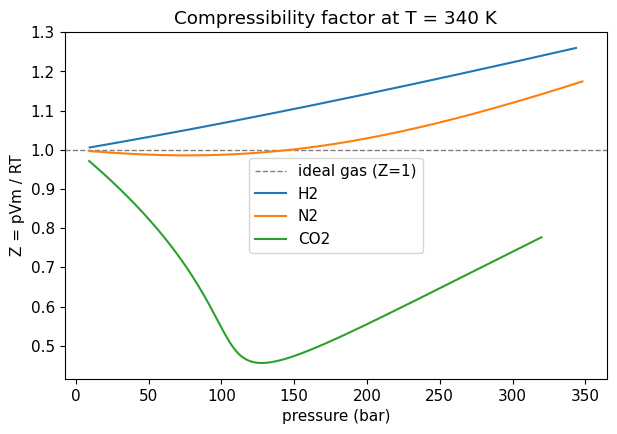

In [3]:
# van der Waals coefficients for a few real gases
# a in L^2 bar / mol^2, b in L / mol
vdw_params = {
    "H2":  {"a": 0.2453, "b": 0.02651},
    "N2":  {"a": 1.370,  "b": 0.0387},
    "CO2": {"a": 3.658,  "b": 0.04286},
}

R = 0.083145  # L bar / (mol K)
T = 340.0     # K -- chosen above the critical temperature of all three gases
              # (Tc: H2 = 33 K, N2 = 126 K, CO2 = 304 K) so each isotherm is smooth,
              # i.e. there's no gas-liquid phase transition happening in this range

def vdw_pressure(Vm, a, b, T):
    """van der Waals pressure (bar) as a function of molar volume Vm (L/mol)."""
    return R * T / (Vm - b) - a / Vm**2

plt.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="ideal gas (Z=1)")

for name, p in vdw_params.items():
    Vm = np.linspace(p["b"] * 1.05, 3.0, 2000)
    pressure = vdw_pressure(Vm, p["a"], p["b"], T)
    Z = pressure * Vm / (R * T)

    mask = (pressure > 0) & (pressure < 350)
    plt.plot(pressure[mask], Z[mask], label=name)

plt.xlabel("pressure (bar)")
plt.ylabel("Z = pVm / RT")
plt.title(f"Compressibility factor at T = {T:.0f} K")
plt.legend()
plt.show()

**Questions to think about:**

- Which gas deviates the most from ideal behavior? Look at its $a$ value in the table - is it the largest?
- At low pressure, is $Z$ above or below 1 for CO$_2$? What about at very high pressure? Which term ($a$ or $b$) is winning in each regime?
- Try changing `T` in the cell above to something closer to CO$_2$'s critical temperature (304 K, but stay above it, e.g. 310 K) and see how much more dramatic the dip becomes.

## Part 3 - Simulating a 2D Lennard-Jones gas: condensation and g(r)

Here we simulate a small box of particles interacting through the Lennard-Jones potential, using simple Newtonian dynamics (velocity Verlet integration). We work in **reduced units** where $\sigma = 1$, $\varepsilon = 1$, $m = 1$, $k_B = 1$ - this is standard practice in molecular simulation and keeps the numbers simple. Real temperature then becomes $T^* = k_BT/\varepsilon$.

We'll run the same simulation at a high $T^*$ (gas-like) and a low $T^*$ (liquid-like) and compare:

- what the particles look like in the box
- the pair correlation function g(r) computed from the particle positions

This is the same physical idea as the interactive demo, but here you have the full code to modify.

In [4]:
def run_lj_simulation(T_star, N=60, L=11.0, n_steps=3000, dt=0.006, rc=2.8, seed=0):
    """
    Run a 2D Lennard-Jones molecular dynamics simulation with periodic boundaries.

    T_star : target temperature in reduced units (k_B T / epsilon)
    N      : number of particles
    L      : box side length (reduced units, sigma = 1)
    n_steps: number of integration steps
    dt     : time step
    rc     : cutoff radius for the potential (for speed)

    Returns final positions and the trajectory of the last few frames (for g(r) averaging).
    """
    rng = np.random.default_rng(seed)

    # start particles on a grid so none of them overlap
    per_row = int(np.ceil(np.sqrt(N)))
    spacing = L / per_row
    pos = np.array([[ (i + 0.5) * spacing, (j + 0.5) * spacing ]
                     for i in range(per_row) for j in range(per_row)])[:N]
    pos += rng.uniform(-0.05, 0.05, pos.shape)

    speed = np.sqrt(T_star)
    vel = rng.normal(0, speed, size=(N, 2))

    def forces(pos):
        f = np.zeros_like(pos)
        for i in range(N):
            dr = pos[i] - pos
            dr -= L * np.round(dr / L)          # minimum image convention
            r2 = np.sum(dr**2, axis=1)
            r2[i] = np.inf                       # exclude self
            mask = r2 < rc**2
            r2m = r2[mask]
            r2i = 1.0 / r2m
            r6i = r2i**3
            fmag = 48 * r6i**2 * r2i - 24 * r6i * r2i   # -du/dr / r, in LJ reduced units
            f[i] += np.sum(fmag[:, None] * dr[mask], axis=0)
        return f

    frames = []
    f = forces(pos)
    for step in range(n_steps):
        vel += 0.5 * f * dt
        pos = (pos + vel * dt) % L
        f = forces(pos)
        vel += 0.5 * f * dt

        # simple velocity rescaling thermostat: gently nudge kinetic energy toward target T*
        T_inst = np.sum(vel**2) / (2 * N)
        lam = np.sqrt(1 + 0.03 * (T_star / max(T_inst, 1e-3) - 1))
        vel *= lam

        if step > n_steps - 400 and step % 4 == 0:   # collect frames near the end, once equilibrated
            frames.append(pos.copy())

    return pos, frames, L, N


def pair_correlation(frames, L, N, n_bins=50, r_max=None):
    """Compute the 2D pair correlation function g(r) averaged over a list of frames."""
    if r_max is None:
        r_max = L / 2
    dr = r_max / n_bins
    hist = np.zeros(n_bins)
    rho = N / L**2

    for pos in frames:
        for i in range(N):
            dr_vec = pos[i] - pos
            dr_vec -= L * np.round(dr_vec / L)
            dist = np.sqrt(np.sum(dr_vec**2, axis=1))
            dist[i] = np.inf
            bins = (dist[dist < r_max] / dr).astype(int)
            for b in bins:
                hist[b] += 1

    r_edges = np.arange(n_bins + 1) * dr
    shell_areas = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2)
    ideal_counts = N * rho * shell_areas * len(frames)
    g = hist / ideal_counts
    r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
    return r_centers, g

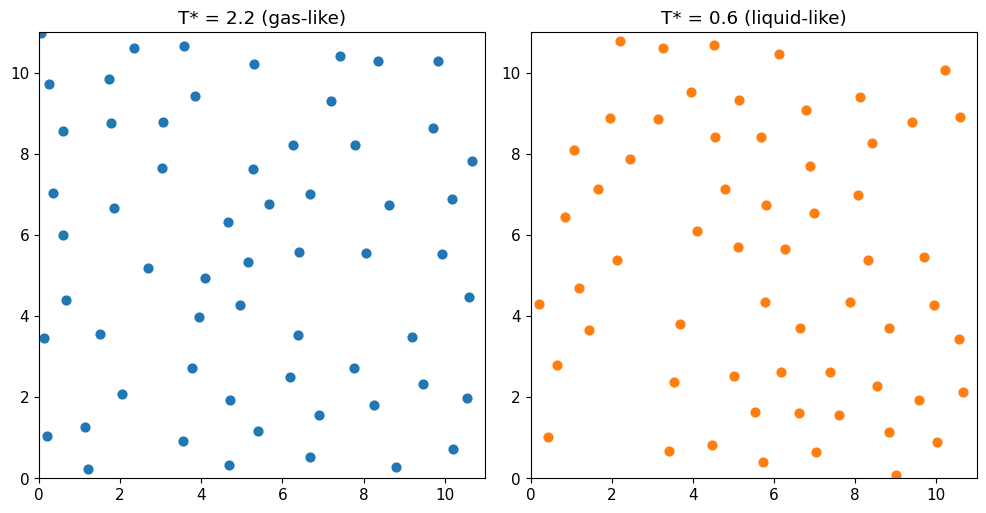

In [5]:
# Run the "gas" case: high temperature, weak effective clustering
pos_gas, frames_gas, L, N = run_lj_simulation(T_star=2.2, seed=1)

# Run the "liquid" case: low temperature, strong clustering
pos_liq, frames_liq, L, N = run_lj_simulation(T_star=0.6, seed=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(pos_gas[:, 0], pos_gas[:, 1], s=40)
axes[0].set_title("T* = 2.2 (gas-like)")
axes[0].set_xlim(0, L); axes[0].set_ylim(0, L); axes[0].set_aspect("equal")

axes[1].scatter(pos_liq[:, 0], pos_liq[:, 1], s=40, color="tab:orange")
axes[1].set_title("T* = 0.6 (liquid-like)")
axes[1].set_xlim(0, L); axes[1].set_ylim(0, L); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

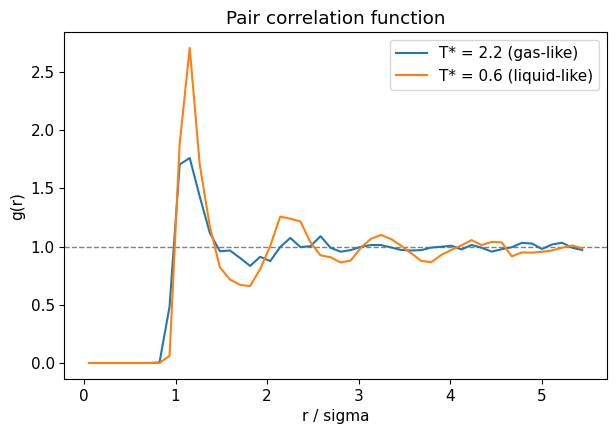

In [6]:
r_gas, g_gas = pair_correlation(frames_gas, L, N)
r_liq, g_liq = pair_correlation(frames_liq, L, N)

plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.plot(r_gas, g_gas, label="T* = 2.2 (gas-like)")
plt.plot(r_liq, g_liq, label="T* = 0.6 (liquid-like)")
plt.xlabel("r / sigma")
plt.ylabel("g(r)")
plt.title("Pair correlation function")
plt.legend()
plt.show()

**Questions to think about:**

- In the gas case, does g(r) stay close to 1 at all distances, or does it show structure? What about the liquid case?
- The first peak in g(r) tells you the most likely distance to the nearest neighbor. Does that distance change much between the gas and liquid cases? (Hint: it shouldn't - the well minimum of the LJ potential doesn't depend on temperature, only how strongly molecules pile up there does.)
- Try running the simulation at an intermediate `T_star` (e.g. 1.0 or 1.3) - does the transition from gas-like to liquid-like happen gradually or fairly suddenly?
- This is a purely repulsion + attraction (Lennard-Jones) model. What extra piece of physics would you need to add to make this a reasonable model of water instead of argon?

**Note:** this simulation is intentionally small (60 particles, a few thousand steps) so it runs quickly in a notebook. It is a simplified illustration of molecular dynamics, not a research-grade simulation - real studies use thousands of particles, longer equilibration, and more careful thermostats.